# Manifolds and Lie Groups Visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

In [2]:
def set_axes_equal_3d(ax):
    """
    Set equal scaling for a 3D matplotlib axis.

    Matplotlib does not automatically use equal aspect ratio in 3D plots.
    This helper makes spheres look like spheres instead of ellipsoids.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    radius = max_range / 2

    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])

## Demo 1 — Embedding dimension vs intrinsic dimension

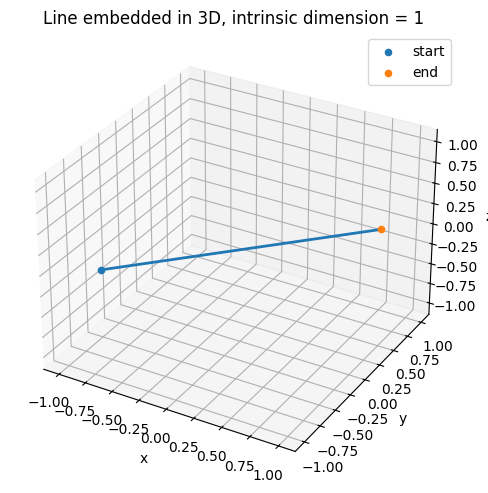

In [3]:
# A line in 3D can be described by one parameter t.
t = np.linspace(-1.0, 1.0, 200)

# Parametric line: p(t) = p0 + t * direction
p0 = np.array([0.0, 0.0, 0.0])
direction = np.array([1.0, 0.5, 0.3])

line_points = p0[:, None] + direction[:, None] * t

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    line_points[0],
    line_points[1],
    line_points[2],
    linewidth=2,
)

ax.scatter(line_points[0, 0], line_points[1, 0], line_points[2, 0], label="start")
ax.scatter(line_points[0, -1], line_points[1, -1], line_points[2, -1], label="end")

ax.set_title("Line embedded in 3D, intrinsic dimension = 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

set_axes_equal_3d(ax)
plt.tight_layout()

plt.savefig(figures_dir / "line_embedded_in_3d.png", dpi=200)
plt.show()

Although this line is drawn in three-dimensional space, points on the line are determined by a single parameter $t$.
Therefore, its intrinsic dimension is 1, while its embedding dimension is 3.

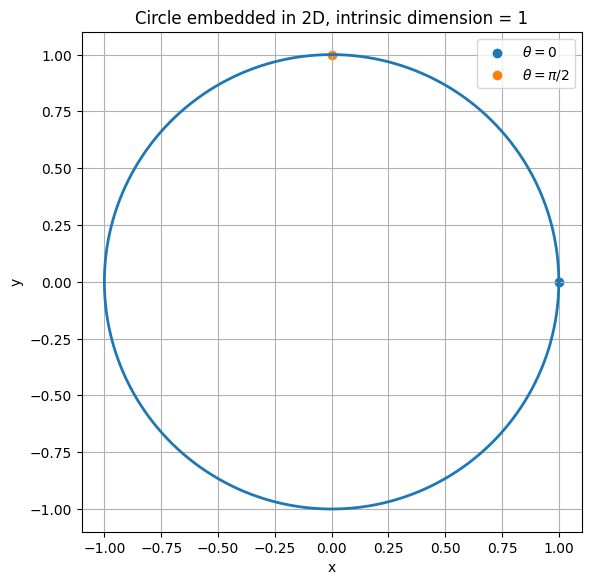

In [4]:
# A circle in 2D can be described by one parameter theta.
theta = np.linspace(0.0, 2.0 * np.pi, 400)

x = np.cos(theta)
y = np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x, y, linewidth=2)
ax.scatter([1.0], [0.0], label=r"$\theta = 0$")
ax.scatter([0.0], [1.0], label=r"$\theta = \pi/2$")

ax.set_title("Circle embedded in 2D, intrinsic dimension = 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "circle_embedded_in_2d.png", dpi=200)
plt.show()

The circle is embedded in two-dimensional space because it is drawn using \(x\) and \(y\) coordinates.
However, a point constrained to the circle can be described using only one independent parameter,
the angle \(\theta\). Therefore, the circle has intrinsic dimension 1.

## Demo 2 — Sphere surface as a 2D manifold embedded in 3D

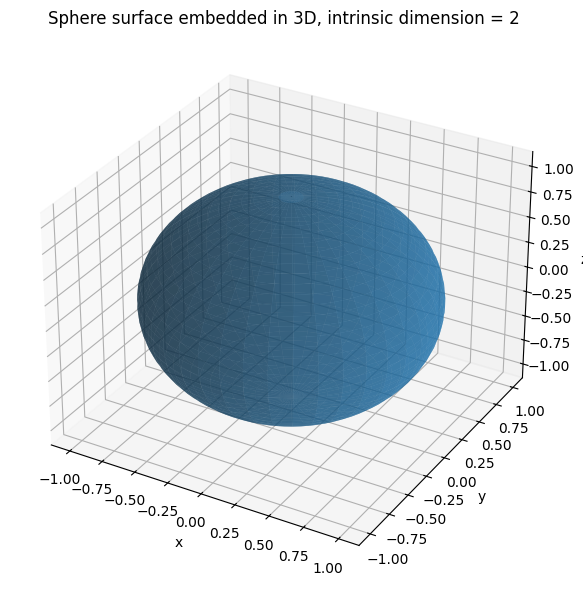

In [5]:
# A sphere surface in 3D can be described by two parameters:
# theta: azimuth angle
# phi: polar angle

theta = np.linspace(0.0, 2.0 * np.pi, 80)
phi = np.linspace(0.0, np.pi, 40)

theta_grid, phi_grid = np.meshgrid(theta, phi)

x = np.sin(phi_grid) * np.cos(theta_grid)
y = np.sin(phi_grid) * np.sin(theta_grid)
z = np.cos(phi_grid)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(x, y, z, alpha=0.6, linewidth=0)

ax.set_title("Sphere surface embedded in 3D, intrinsic dimension = 2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

set_axes_equal_3d(ax)
plt.tight_layout()

plt.savefig(figures_dir / "sphere_surface_embedded_in_3d.png", dpi=200)
plt.show()

The sphere surface is embedded in three-dimensional space because each point has coordinates $(x, y, z)$.
However, if motion is constrained to the surface, only two independent coordinates are needed locally.
For example, a point on the unit sphere can be parameterized by two angles: $\theta$ and $\phi$.
Therefore, the sphere surface has intrinsic dimension 2.

In [6]:
import pandas as pd

summary = pd.DataFrame(
    {
        "Object": [
            "Line in 3D",
            "Circle in 2D",
            "Sphere surface in 3D",
        ],
        "Embedding dimension": [
            3,
            2,
            3,
        ],
        "Intrinsic dimension": [
            1,
            1,
            2,
        ],
        "Independent parameters": [
            "t",
            "theta",
            "theta, phi",
        ],
    }
)

summary

,Object,Embedding dimension,Intrinsic dimension,Independent parameters
0,Line in 3D,3,1,t
1,Circle in 2D,2,1,theta
2,Sphere surface in 3D,3,2,"theta, phi"


The intrinsic dimension tells us how many independent coordinates are needed
to describe motion constrained to the object.
This is different from the embedding dimension,
which tells us the dimension of the surrounding space in which the object is represented.

This distinction is important in robotics because rotation matrices in $SO(3)$
are represented as $3 \times 3$ matrices with nine entries,
but the space of valid 3D rotations has only three intrinsic degrees of freedom.

## Demo 3 — Rotation matrices are constrained objects

## Demo 4 — Local updates on SO(3) using the exponential map